In [8]:
import control
import numpy as np
import matplotlib.pyplot as plt

import seisim.system
import seisim.predictor
import seisim.controller
import seisim.seisim


data = np.loadtxt("test_data/itmx_z_1441947618_64hz.txt")

t, ground_motion = data
dt = t[1] - t[0]

n_predict = int(1/dt)
n_control = int(1/dt)  # 1 seconds


s = control.tf("s")
wn = 7.85398163397
q = 1.11111111
tf = wn**2 / (s**2 + wn/q*s + wn**2)

system = seisim.system.System(tf, dt)

predictor = seisim.predictor.ConstantOrder(dt=dt, order=7, n_predict=n_predict)

controller = seisim.controller.MPCFF(
    model=None, n_predict=n_predict, n_control=n_control, predictor=predictor)

seisim = seisim.seisim.Seisim(system=system, controller=controller)

In [9]:
motion = seisim.simulate(t, ground_motion)

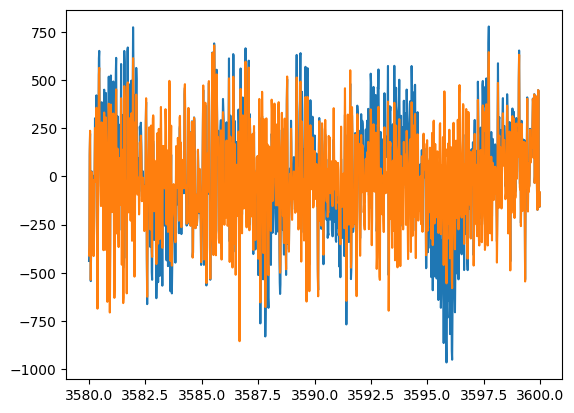

In [17]:
plt.plot(t[-1280:], ground_motion[-1280:])
plt.plot(t[-1280:], motion[-1280:])

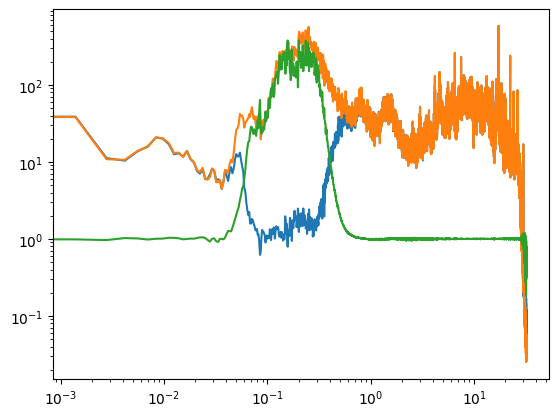

In [15]:
import scipy.signal


f, pyy = scipy.signal.welch(ground_motion, fs=1/dt, nperseg=int(len(ground_motion)/5))
f, pyy_ = scipy.signal.welch(motion, fs=1/dt, nperseg=int(len(motion)/5))

ayy = pyy**.5
ayy_ = pyy_**.5

plt.loglog(f, ayy)
plt.loglog(f, ayy_)

plt.loglog(f, ayy/ayy_)